# Investigation 02 - 4D Metric Correlation Bubble Plot


In [129]:
import ast
import os
import sys
sys.path.append(os.path.abspath('../../'))
from utils.rules import _extract_base_lineage

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib.patches import Rectangle

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 120


In [ ]:
# ---------- Main toggles ----------
METHOD = "CN"
ORGAN = "Colon"   # "Colon", "Duodenum", or None
ORGAN_COLUMN = "Organ"
NO_SELF = True
SUBSET_RULE_ITEMS_MAX = 2
SUBSET_MIN_SUPPORT = 0.0
STAGE_COLUMN = "Clinical score"
FDR_COLUMN = "FDR"
FDR_MAX = 0.05

STAGE = "Mild"  # e.g., "Control", "Mild", "Severe", or 0, 1, 2
# ---------- Bubble thresholds ----------
POS_LEVERAGE_MIN = 0.05
POS_LIFT_MIN = 1.2
NEG_LEVERAGE_MAX = -0.05
NEG_LIFT_MAX = 0.6

# ---------- Bubble display ----------
MIN_SUPPORT_FOR_BUBBLE = 0.0
BUBBLE_SIZE_SCALE = 2000
NOISE_LEVERAGE_ABS = 0.01
NOISE_LIFT_RANGE = (0.8, 1.2)

# ---------- Data path ----------
ALGO = "min_support_runs\weighted_fpgrowth_no_markers"  # e.g., "fpgrowth", "weighted_fpgrowth"
DATA_ROOT = fr"results\full_run\{ALGO}\data"
RAW_RESULTS_FILE = os.path.join("..", "..", DATA_ROOT, f"results_{METHOD}.csv")

print("METHOD:", METHOD)
print("ORGAN:", ORGAN)
print("NO_SELF:", NO_SELF)
print("SUBSET_RULE_ITEMS_MAX:", SUBSET_RULE_ITEMS_MAX)
print("SUBSET_MIN_SUPPORT:", SUBSET_MIN_SUPPORT)
print("FDR_MAX:", FDR_MAX)
print("RAW_RESULTS_FILE:", RAW_RESULTS_FILE)

# ---------- Highlight specific rules ----------
HIGHLIGHT_RULES = [
    # r"Paneth.*->.*Epithelial.*",
    # r"Macrophage.*->.*Epithelial.*",
    # r"Plasma.*->.*Epithelial.*",
    # r"CD8T.*->.*Epithelial.*",
    # r"Neutrophil.*->.*Epithelial.*",
    # r"Macrophage.*-> CD8T.*",
    # r"Endocrine.*->.*Muscle.*",
    # r"Fibroblast.*->.*Epithelial.*"
    r"Epithelial.*->.*.*",
    r".*->.*Epithelial.*",

    r"Fibroblast.*->.*.*",
    r".*->.*Fibroblast.*",

    r"CD4T.*->.*.*",
    r".*->.*CD4T.*",

    r"Macrophage.*->.*.*",
    r".*->.*Macrophage.*",

    r"Neuron.*->.*.*",
    r".*->.*Neuron.*",

]


METHOD: CN
ORGAN: Colon
NO_SELF: True
SUBSET_RULE_ITEMS_MAX: 2
SUBSET_MIN_SUPPORT: 0.0
FDR_MAX: 0.05
RAW_RESULTS_FILE: ..\..\results\full_run\fpgrowth_old\data\results_CN.csv


In [131]:
def _plot_metric_bubble(metric_df, leverage_source):
    if metric_df.empty:
        print("No rows after filtering. Adjust filters or thresholds.")
        return None

    fig, ax = plt.subplots(figsize=(14, 10))

    scatter = ax.scatter(
        metric_df["Leverage"],
        metric_df["Log2_Lift"],
        s=metric_df["Bubble_Size"],
        c=metric_df["Confidence"],
        cmap="viridis",
        alpha=0.75,
        edgecolors="black",
        linewidths=0.3,
    )

    ax.axvline(0, color="gray", linewidth=1.0)
    ax.axhline(0, color="gray", linewidth=1.0)
    ax.axvline(POS_LEVERAGE_MIN, color="tomato", linestyle="--", linewidth=1.0)
    ax.axhline(np.log2(POS_LIFT_MIN), color="tomato", linestyle="--", linewidth=1.0)
    ax.axvline(NEG_LEVERAGE_MAX, color="royalblue", linestyle="--", linewidth=1.0)
    ax.axhline(np.log2(NEG_LIFT_MAX), color="royalblue", linestyle="--", linewidth=1.0)

    x_min, x_max = metric_df["Leverage"].min(), metric_df["Leverage"].max()
    y_min, y_max = metric_df["Log2_Lift"].min(), metric_df["Log2_Lift"].max()

    if x_max > POS_LEVERAGE_MIN and y_max > np.log2(POS_LIFT_MIN):
        pos_rect = Rectangle(
            (POS_LEVERAGE_MIN, np.log2(POS_LIFT_MIN)),
            x_max - POS_LEVERAGE_MIN,
            y_max - np.log2(POS_LIFT_MIN),
            fill=False,
            edgecolor="tomato",
            linewidth=1.2,
        )
        ax.add_patch(pos_rect)

    if x_min < NEG_LEVERAGE_MAX and y_min < np.log2(NEG_LIFT_MAX):
        neg_rect = Rectangle(
            (x_min, y_min),
            NEG_LEVERAGE_MAX - x_min,
            np.log2(NEG_LIFT_MAX) - y_min,
            fill=False,
            edgecolor="royalblue",
            linewidth=1.2,
        )
        ax.add_patch(neg_rect)

    colorbar = plt.colorbar(scatter, ax=ax)
    colorbar.set_label("Confidence")

    # --- Highlight specific rules ---
    if "HIGHLIGHT_RULES" in globals() and HIGHLIGHT_RULES:
        import re
        pattern = "|".join(HIGHLIGHT_RULES)
        mask = metric_df["Rule"].str.contains(pattern, regex=True, na=False)
        hl_df = metric_df[mask]
        if not hl_df.empty:
            ax.scatter(
                hl_df["Leverage"],
                hl_df["Log2_Lift"],
                s=hl_df["Bubble_Size"],
                facecolors="none",
                edgecolors="red",
                linewidths=2.5,
                zorder=5,
            )
            from adjustText import adjust_text
            texts = []
            for _, row in hl_df.iterrows():
                texts.append(ax.text(
                    row["Leverage"],
                    row["Log2_Lift"],
                    row["Rule"],
                    color="red",
                    fontsize=9,
                    zorder=6,
                ))
            adjust_text(texts, arrowprops=dict(arrowstyle="-", color='red', lw=0.5))

    supports = metric_df["Support"].quantile([0.1, 0.5, 0.75, 0.9]).values
    handles = [
        ax.scatter([], [], s=max(s * BUBBLE_SIZE_SCALE, 10), color="gray", alpha=0.35, edgecolors="none")
        for s in supports
    ]
    labels = [f"Support {s:.3f}" for s in supports]
    ax.legend(handles, labels, title="Bubble size", loc="upper left")

    positive_count = int(((metric_df["Leverage"] >= POS_LEVERAGE_MIN) & (metric_df["Log2_Lift"] >= np.log2(POS_LIFT_MIN))).sum())
    negative_count = int(((metric_df["Leverage"] <= NEG_LEVERAGE_MAX) & (metric_df["Log2_Lift"] <= np.log2(NEG_LIFT_MAX))).sum())
    dot_count = int(metric_df.shape[0])

    organ_text = ORGAN if ORGAN is not None else "All"
    stage_text = STAGE if STAGE is not None else "All"
    
    title_lines = [
        f"4D Metric Correlation Bubble Plot ({METHOD} | {ALGO})",
        f"Organ: {organ_text}  |  Stage Col: {STAGE_COLUMN}  |  Stage: {stage_text}",
        f"Filters: No Self-Loops={NO_SELF}  |  Max Items={SUBSET_RULE_ITEMS_MAX}  |  Min Support={SUBSET_MIN_SUPPORT}  |  FDR < {FDR_MAX}"
    ]
    
    ax.set_title(
        "\n".join(title_lines), 
        pad=20, loc="left", fontsize=11, fontweight="bold", linespacing=1.5
    )
    ax.set_xlabel("Leverage")
    ax.set_ylabel("log2(Lift)")
    ax.text(
        0.01,
        -0.12,
        f"Dots: {dot_count} | Positive: {positive_count} | Negative: {negative_count}",
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=10,
    )
    fig.subplots_adjust(bottom=0.16)

    return fig


def _summarize_threshold_zones(metric_df):
    positive_zone = (metric_df["Leverage"] >= POS_LEVERAGE_MIN) & (metric_df["Log2_Lift"] >= np.log2(POS_LIFT_MIN))
    negative_zone = (metric_df["Leverage"] <= NEG_LEVERAGE_MAX) & (metric_df["Log2_Lift"] <= np.log2(NEG_LIFT_MAX))
    noise_zone = (metric_df["Leverage"].abs() <= NOISE_LEVERAGE_ABS) & ((metric_df["Lift"] >= NOISE_LIFT_RANGE[0]) & (metric_df["Lift"] <= NOISE_LIFT_RANGE[1]))

    summary = pd.DataFrame(
        {
            "Zone": ["Positive zone", "Negative zone", "Noise zone", "Total"],
            "Count": [int(positive_zone.sum()), int(negative_zone.sum()), int(noise_zone.sum()), int(metric_df.shape[0])],
        }
    )
    summary["Percent"] = (summary["Count"] / max(metric_df.shape[0], 1) * 100).round(2)
    return summary



def _add_organ_metadata(work_df):
    import os
    import pandas as pd
    
    if "Organ" in work_df.columns:
        return work_df
        
    mibi_gut_dir_path = os.path.join("..", "..", "data", "MIBIGutCsv")
    biopsy_path = os.path.join(mibi_gut_dir_path, "biopsy_metadata.csv")
    fovs_path = os.path.join(mibi_gut_dir_path, "fovs_metadata.csv")

    if os.path.exists(biopsy_path) and os.path.exists(fovs_path):
        df_biopsy = pd.read_csv(biopsy_path)
        df_fovs = pd.read_csv(fovs_path)
        unique_biopsies = df_fovs[~df_fovs["FOV"].astype(str).str.startswith("S_")][["Patient", "Cohort"]].drop_duplicates().rename(columns={"Patient": "Biopsy_ID"})
        meta = pd.merge(unique_biopsies, df_biopsy[["Biopsy_ID", "Localization"]], on="Biopsy_ID", how="left")

        def get_organ(row):
            if pd.notna(row.get("Localization")): return row["Localization"]
            cohort = str(row.get("Cohort", ""))
            if "Colon" in cohort: return "Colon"
            if "Duodenum" in cohort: return "Duodenum"
            return "Unknown"

        meta["Organ"] = meta.apply(get_organ, axis=1)
        work_df = work_df.merge(meta[["Biopsy_ID", "Organ"]], on="Biopsy_ID", how="left")
    return work_df



def _plot_highlight_rules_table(organ):
    import re
    import numpy as np
    import ast
    import matplotlib.pyplot as plt
    from pandas.plotting import table

    if not "HIGHLIGHT_RULES" in globals() or not HIGHLIGHT_RULES:
        return None

    pattern = "|".join(HIGHLIGHT_RULES)
    test_df = raw_results_df.copy()
    test_df = _add_organ_metadata(test_df)
    
    if organ is not None:
        test_df = test_df[test_df["Organ"].astype(str) == str(organ)].copy()
        
    test_df["Item_Count"] = (
        test_df["Antecedents"].apply(ast.literal_eval).apply(len) +
        test_df["Consequents"].apply(ast.literal_eval).apply(len)
    )

    test_df["Rule_Clean"] = (
        test_df["Antecedents"].astype(str).str.replace("_CENTER", "").str.replace("_NEIGHBOR", "").str.replace("['", "").str.replace("']", "")
        + " -> " +
        test_df["Consequents"].astype(str).str.replace("_CENTER", "").str.replace("_NEIGHBOR", "").str.replace("['", "").str.replace("']", "")
    )

    if SUBSET_RULE_ITEMS_MAX is not None:
        test_df = test_df[test_df["Item_Count"] <= SUBSET_RULE_ITEMS_MAX]
        
    highlight_mask = test_df["Rule_Clean"].str.contains(pattern, regex=True, na=False)
    hl_df = test_df[highlight_mask].copy()

    if hl_df.empty:
        return None

    hl_df["Leverage"] = hl_df["Support"] * (1 - 1 / hl_df["Lift"])
    stats_df = hl_df.groupby(["Rule_Clean", STAGE_COLUMN]).agg(
        FOV_Count=("FOV", "nunique"),
        Mean_Leverage=("Leverage", "mean"),
        Mean_Lift=("Lift", "mean"),
        Mean_Confidence=("Confidence", "mean"),
        Mean_Support=("Support", "mean")
    ).reset_index()

    for col in ["Mean_Leverage", "Mean_Lift", "Mean_Confidence", "Mean_Support"]:
        if col in stats_df.columns:
            stats_df[col] = stats_df[col].round(3)

    import textwrap
    stats_df["Rule_Clean"] = stats_df["Rule_Clean"].apply(lambda x: textwrap.fill(x, width=45))

    fig, ax = plt.subplots(figsize=(14, max(2, len(stats_df) * 0.7)))
    ax.axis("off")
    
    col_labels = stats_df.columns.tolist()
    cell_text = stats_df.values.tolist()
    col_widths = [0.4, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1]
    
    tbl = ax.table(cellText=cell_text, colLabels=col_labels, loc="center", cellLoc="center", colWidths=col_widths)
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(10)
    tbl.scale(1, 3.0)
    
    for key, cell in tbl.get_celld().items():
        cell.set_edgecolor('lightgray')
        if key[0] == 0:
            cell.set_text_props(weight='bold')
            cell.set_facecolor('#f2f2f2')
    
    title_text = f"Highlighted Rules Metrics ({METHOD} | {ALGO}) | Organ: {organ} | Items <= {SUBSET_RULE_ITEMS_MAX}"
    ax.set_title(title_text, pad=20, loc="center", fontsize=12, fontweight="bold")
    
    return fig


### Load Raw Data

In [132]:
raw_results_df = pd.read_csv(RAW_RESULTS_FILE)
raw_results_df = raw_results_df[raw_results_df["FDR"] <= FDR_MAX].copy()
print("raw_results_df:", raw_results_df.shape)
raw_results_df.head(3)


raw_results_df: (18574, 22)


,FOV,Antecedents,Consequents,Lift,Confidence,Conviction,Support,P_Value,FDR,Rule_Count_Global,...,Cortico Response,Survival at follow-up,GI stage,Grade GVHD,liver stage,skin stage,Pathological stage,Clinical score,Pathological score,Group
0,Control_01_FOV_1,"['CD4T_CENTER', 'SMV_NEIGHBOR']","['CD4T_NEIGHBOR', 'Macrophage_NEIGHBOR']",1.278853,0.904255,3.059357,0.102041,0.000999,0.001008,2,...,Control,Control,0.0,0.0,0.0,0.0,0.0,Control,Control,0.0
1,Control_01_FOV_1,"['CD4T_CENTER', 'Endothelial_NEIGHBOR']",['SMV_NEIGHBOR'],1.482535,0.720207,1.837809,0.055622,0.000999,0.001008,2,...,Control,Control,0.0,0.0,0.0,0.0,0.0,Control,Control,0.0
2,Control_01_FOV_1,"['CD4T_CENTER', 'Endothelial_NEIGHBOR']","['CD4T_NEIGHBOR', 'Macrophage_NEIGHBOR']",1.245723,0.880829,2.457957,0.068027,0.000999,0.001008,2,...,Control,Control,0.0,0.0,0.0,0.0,0.0,Control,Control,0.0


In [133]:
import re
import numpy as np

ORGAN = "Colon"   # "Colon", "Duodenum", or None
pattern = "|".join(HIGHLIGHT_RULES)
print("Regex pattern for highlighting:", pattern)

# 1. Create a clean rule string directly on the raw data (bypassing all filters)
test_df = raw_results_df.copy()
test_df = _add_organ_metadata(test_df)
if ORGAN is not None:
    test_df = test_df[test_df["Organ"].astype(str) == str(ORGAN)].copy()
test_df["Item_Count"] = (
    test_df["Antecedents"].apply(ast.literal_eval).apply(len) +
    test_df["Consequents"].apply(ast.literal_eval).apply(len)
)

test_df["Rule_Clean"] = (
    test_df["Antecedents"].astype(str).str.replace("_CENTER", "").str.replace("_NEIGHBOR", "").str.replace("['", "").str.replace("']", "")
    + " -> " +
    test_df["Consequents"].astype(str).str.replace("_CENTER", "").str.replace("_NEIGHBOR", "").str.replace("['", "").str.replace("']", "")
    )

test_df = test_df[test_df["Item_Count"] <= SUBSET_RULE_ITEMS_MAX]
# 2. Search for the pattern
highlight_mask = test_df["Rule_Clean"].str.contains(pattern, regex=True, na=False)
matching_rows = test_df[highlight_mask]

# Extract just the rows for your highlighted rules
hl_df = test_df[highlight_mask].copy()

if not hl_df.empty:
    # 1. Calculate Leverage for each FOV (Support * (1 - 1/Lift))
    hl_df["Leverage"] = hl_df["Support"] * (1 - 1 / hl_df["Lift"])

    # 2. Group by Rule and Stage to calculate means AND count the unique FOVs
    stats_df = hl_df.groupby(["Rule_Clean", STAGE_COLUMN]).agg(
        FOV_Count=("FOV", "nunique"),
        Mean_Leverage=("Leverage", "mean"),
        Mean_Lift=("Lift", "mean"),
        Mean_Confidence=("Confidence", "mean"),
        Mean_Support=("Support", "mean")
    ).reset_index()

    print(f"\n--- Metrics per Stage for '{ORGAN}' ---")
    display(stats_df)
else:
    print(f"\n--- No matching rules found for '{ORGAN}' in this filtered dataset ---")

Regex pattern for highlighting: Epithelial.*->.*.*|.*->.*Epithelial.*|Fibroblast.*->.*.*|.*->.*Fibroblast.*|CD4T.*->.*.*|.*->.*CD4T.*|Macrophage.*->.*.*|.*->.*Macrophage.*|Neuron.*->.*.*|.*->.*Neuron.*

--- Metrics per Stage for 'Colon' ---


,Rule_Clean,Clinical score,FOV_Count,Mean_Leverage,Mean_Lift,Mean_Confidence,Mean_Support
0,CD4T -> APC,Severe,1,0.055870,1.950697,0.836013,0.114638
1,CD4T -> CD4T,Control,6,0.016994,1.445836,0.889413,0.055619
2,CD4T -> CD4T,Mild,1,0.029511,1.634047,0.961538,0.076054
3,CD4T -> CD4T,Severe,9,0.034450,1.569957,0.956623,0.098126
4,CD4T -> CD8T,Control,1,0.018959,1.434478,0.905797,0.062594
...,...,...,...,...,...,...,...
113,Plasma -> Macrophage,Control,8,0.018670,1.234734,0.943003,0.098672
114,SMV -> Fibroblast,Mild,1,0.010867,1.210275,0.956522,0.062544
115,SMV -> Fibroblast,Severe,5,0.013566,1.267665,0.952892,0.065265
116,SMV -> Macrophage,Mild,5,0.014129,1.299770,0.956909,0.063534


In [134]:
import re
import numpy as np

ORGAN = "Duodenum"   # "Colon", "Duodenum", or None
pattern = "|".join(HIGHLIGHT_RULES)
print("Regex pattern for highlighting:", pattern)

# 1. Create a clean rule string directly on the raw data (bypassing all filters)
test_df = raw_results_df.copy()
test_df = _add_organ_metadata(test_df)
if ORGAN is not None:
    test_df = test_df[test_df["Organ"].astype(str) == str(ORGAN)].copy()
test_df["Item_Count"] = (
    test_df["Antecedents"].apply(ast.literal_eval).apply(len) +
    test_df["Consequents"].apply(ast.literal_eval).apply(len)
)

test_df["Rule_Clean"] = (
    test_df["Antecedents"].astype(str).str.replace("_CENTER", "").str.replace("_NEIGHBOR", "").str.replace("['", "").str.replace("']", "")
    + " -> " +
    test_df["Consequents"].astype(str).str.replace("_CENTER", "").str.replace("_NEIGHBOR", "").str.replace("['", "").str.replace("']", "")
    )

test_df = test_df[test_df["Item_Count"] <= SUBSET_RULE_ITEMS_MAX]
# 2. Search for the pattern
highlight_mask = test_df["Rule_Clean"].str.contains(pattern, regex=True, na=False)
matching_rows = test_df[highlight_mask]

# Extract just the rows for your highlighted rules
hl_df = test_df[highlight_mask].copy()

if not hl_df.empty:
    # 1. Calculate Leverage for each FOV (Support * (1 - 1/Lift))
    hl_df["Leverage"] = hl_df["Support"] * (1 - 1 / hl_df["Lift"])

    # 2. Group by Rule and Stage to calculate means AND count the unique FOVs
    stats_df = hl_df.groupby(["Rule_Clean", STAGE_COLUMN]).agg(
        FOV_Count=("FOV", "nunique"),
        Mean_Leverage=("Leverage", "mean"),
        Mean_Lift=("Lift", "mean"),
        Mean_Confidence=("Confidence", "mean"),
        Mean_Support=("Support", "mean")
    ).reset_index()

    print(f"\n--- Metrics per Stage for '{ORGAN}' ---")
    display(stats_df)
else:
    print(f"\n--- No matching rules found for '{ORGAN}' in this filtered dataset ---")

Regex pattern for highlighting: Epithelial.*->.*.*|.*->.*Epithelial.*|Fibroblast.*->.*.*|.*->.*Fibroblast.*|CD4T.*->.*.*|.*->.*CD4T.*|Macrophage.*->.*.*|.*->.*Macrophage.*|Neuron.*->.*.*|.*->.*Neuron.*

--- Metrics per Stage for 'Duodenum' ---


,Rule_Clean,Clinical score,FOV_Count,Mean_Leverage,Mean_Lift,Mean_Confidence,Mean_Support
0,APC -> CD4T,Mild,1,0.015971,1.271793,0.740741,0.074731
1,BrunnerGland -> Epithelial,Mild,1,-0.074438,0.472644,0.312925,0.066715
2,BrunnerGland -> Macrophage,Mild,1,-0.037122,0.579040,0.489011,0.051061
3,BrunnerGland -> Macrophage,Severe,1,-0.026868,0.678820,0.594203,0.056787
4,CD4T -> APC,Mild,1,0.025172,1.342803,0.726804,0.098601
...,...,...,...,...,...,...,...
173,SMV -> Macrophage,Mild,14,0.017312,1.296438,0.881851,0.077822
174,SMV -> Macrophage,Severe,1,0.014136,1.206590,0.936842,0.082560
175,SMV -> Neuron,Control,1,0.012536,1.282343,0.844262,0.056938
176,SMV -> Neuron,Mild,5,0.019243,1.347602,0.826929,0.076263


### Build Filtered Bubble Table

In [135]:
def _to_lineage(cell_label):
    return _extract_base_lineage(str(cell_label))


def _create_basic_dataset(raw_results_df):
    work_df = raw_results_df.copy()

    # --- Standardized Organ Enrichment (Inlined from visualization_util logic) ---
    mibi_gut_dir_path = os.path.join("..", "..", "data", "MIBIGutCsv")
    biopsy_path = os.path.join(mibi_gut_dir_path, "biopsy_metadata.csv")
    fovs_path = os.path.join(mibi_gut_dir_path, "fovs_metadata.csv")
    
    if os.path.exists(biopsy_path) and os.path.exists(fovs_path):
        df_biopsy = pd.read_csv(biopsy_path)
        df_fovs = pd.read_csv(fovs_path)
        unique_biopsies = df_fovs[~df_fovs["FOV"].astype(str).str.startswith("S_")][["Patient", "Cohort"]].drop_duplicates().rename(columns={"Patient": "Biopsy_ID"})
        meta = pd.merge(unique_biopsies, df_biopsy[["Biopsy_ID", "Localization"]], on="Biopsy_ID", how="left")
        
        def get_organ(row):
            if pd.notna(row.get("Localization")): return row["Localization"]
            cohort = str(row.get("Cohort", ""))
            if "Colon" in cohort: return "Colon"
            if "Duodenum" in cohort: return "Duodenum"
            return "Unknown"
        
        meta["Organ"] = meta.apply(get_organ, axis=1)
        work_df = work_df.merge(meta[["Biopsy_ID", "Organ"]], on="Biopsy_ID", how="left")
    # -----------------------------------------------------------------------------

    work_df["ant_items"] = work_df["Antecedents"].apply(ast.literal_eval)
    work_df["con_items"] = work_df["Consequents"].apply(ast.literal_eval)
    work_df["ant_clean"] = work_df["ant_items"].apply(
        lambda items: [str(x).replace("_CENTER", "").replace("_NEIGHBOR", "") for x in items]
    )
    work_df["con_clean"] = work_df["con_items"].apply(
        lambda items: [str(x).replace("_CENTER", "").replace("_NEIGHBOR", "") for x in items]
    )
    work_df["ant_lineage"] = work_df["ant_clean"].apply(lambda items: [_to_lineage(x) for x in items])
    work_df["con_lineage"] = work_df["con_clean"].apply(lambda items: [_to_lineage(x) for x in items])
    print(f"Initial rules count: {work_df.shape[0]}")

    if NO_SELF:
        has_overlap = work_df.apply(
            lambda row: len(set(row["ant_lineage"]).intersection(set(row["con_lineage"]))) > 0,
            axis=1,
        )
        work_df = work_df[~has_overlap].copy()
        print(f"Rules count after removing self-overlapping rules: {work_df.shape[0]}")

    if SUBSET_RULE_ITEMS_MAX is not None:
        rule_item_count = work_df.apply(lambda row: len(row["ant_clean"]) + len(row["con_clean"]), axis=1)
        work_df = work_df[rule_item_count <= int(SUBSET_RULE_ITEMS_MAX)].copy()
        print(f"Rules count after filtering by subset rule items: {work_df.shape[0]}")

    if SUBSET_MIN_SUPPORT is not None:
        work_df = work_df[work_df["Support"] >= float(SUBSET_MIN_SUPPORT)].copy()
        print(f"Rules count after filtering by minimum support: {work_df.shape[0]}")

    if STAGE is not None:
        work_df = work_df[work_df[STAGE_COLUMN].astype(str) == str(STAGE)].copy()
        print(f"Rules count after filtering by stage: {work_df.shape[0]}")

    if ORGAN is not None:
        work_df = work_df[work_df["Organ"].astype(str) == str(ORGAN)].copy()
        print(f"Rules count after filtering by organ: {work_df.shape[0]}")

    # --- Safeguard --- 
    if work_df.empty:
        print("Dataset is empty after filtering! Returning early.")
        return work_df
    # -----------------

    work_df["Rule"] = work_df.apply(
        lambda row: f"{', '.join(row['ant_clean'])} -> {', '.join(row['con_clean'])}",
        axis=1,
    )

    return work_df


def _build_metric_bubble_df(work_df):

    if work_df.empty:
        print("Input work_df is empty. Returning empty metric_df.")
        raise ValueError("Input work_df is empty. Cannot build metric_df.")

    metric_df = work_df.copy()
    metric_df = metric_df[metric_df[FDR_COLUMN] < FDR_MAX].copy()
    
    # Defensive checks on the base metrics used in the plot
    metric_df = metric_df[np.isfinite(metric_df["Lift"])].copy()
    metric_df = metric_df[np.isfinite(metric_df["Confidence"])].copy()
    metric_df = metric_df[np.isfinite(metric_df["Support"])].copy()
    metric_df = metric_df[metric_df["Lift"] > 0].copy()

    # 1. Calculate per-FOV metrics FIRST
    # leverage = support - expected_support, and expected_support = support / lift
    metric_df["Leverage"] = metric_df["Support"] * (1 - 1 / metric_df["Lift"])
    
    # Defensive checks on the derived metrics
    metric_df = metric_df[np.isfinite(metric_df["Leverage"])].copy()

    # 2. THEN group by Rule to get the true mathematical mean of all values
    print("metric_df number of lines:", metric_df.shape[0])
    metric_df = metric_df.groupby("Rule", as_index=False)[
        ["Lift", "Confidence", "Support", "Leverage", FDR_COLUMN]
    ].mean()

    metric_df["Log2_Lift"] = np.log2(metric_df["Lift"])
    metric_df = metric_df[np.isfinite(metric_df["Log2_Lift"])].copy()

    # 3. Apply final display filters
    metric_df = metric_df[metric_df["Support"] >= MIN_SUPPORT_FOR_BUBBLE].copy()
    metric_df["Bubble_Size"] = (metric_df["Support"] * BUBBLE_SIZE_SCALE).clip(lower=10)
    
    leverage_source = "mean of per-FOV Leverage"

    return metric_df, leverage_source

    

In [136]:
def _build_and_display_filtered_zone_dataset(metric_df):

    display_cols = ["Rule", "Leverage", "Lift", "Log2_Lift", "Confidence", "Support"]

    # --- Extract and Display Rules for a Selected Zone ---

    # Positive zone:
    zone_mask = (metric_df["Leverage"] >= POS_LEVERAGE_MIN) & (metric_df["Log2_Lift"] >= np.log2(POS_LIFT_MIN))
    sort_col = "Leverage"
    asc = False

    zone_df = metric_df[zone_mask].copy()
    zone_df_display = zone_df[display_cols].sort_values(by=sort_col, ascending=asc)

    print(f"Rules in Positive Zone: {len(zone_df_display)}")
    display(zone_df_display.style.background_gradient(cmap='viridis', subset=["Leverage", "Lift", "Log2_Lift", "Confidence", "Support"]))

    # Negative zone:
    zone_mask = (metric_df["Leverage"] <= NEG_LEVERAGE_MAX) & (metric_df["Log2_Lift"] <= np.log2(NEG_LIFT_MAX))
    sort_col = "Leverage"
    asc = True
    
    zone_df = metric_df[zone_mask].copy()
    zone_df_display = zone_df[display_cols].sort_values(by=sort_col, ascending=asc)

    print(f"Rules in Negative Zone: {len(zone_df_display)}")
    display(zone_df_display.style.background_gradient(cmap='viridis', subset=["Leverage", "Lift", "Log2_Lift", "Confidence", "Support"]))


## Colon's Highest Rules

Initial rules count: 18574
Rules count after removing self-overlapping rules: 10419
Rules count after filtering by subset rule items: 1577
Rules count after filtering by minimum support: 1577
Rules count after filtering by stage: 536
Rules count after filtering by organ: 148
metric_df number of lines: 148
filtered work_df: (148, 30)
metric_df (after FDR + metric filters): (30, 8)
leverage_source: mean of per-FOV Leverage
                        Rule      Lift  Confidence   Support  Leverage  \
0               CD4T -> CD8T  1.434478    0.905797  0.062594  0.018959   
1               CD8T -> CD4T  1.336978    0.763889  0.068084  0.016555   
2             CD8T -> Plasma  1.237677    0.840369  0.068391  0.013102   
3         Epithelial -> CD4T  0.646537    0.299391  0.057544 -0.031631   
4  Epithelial -> Endothelial  0.585804    0.162362  0.054321 -0.038408   
5       Epithelial -> Goblet  1.723504    0.901019  0.148590  0.056126   
6       Epithelial -> Plasma  0.635706    0.379752  0.071

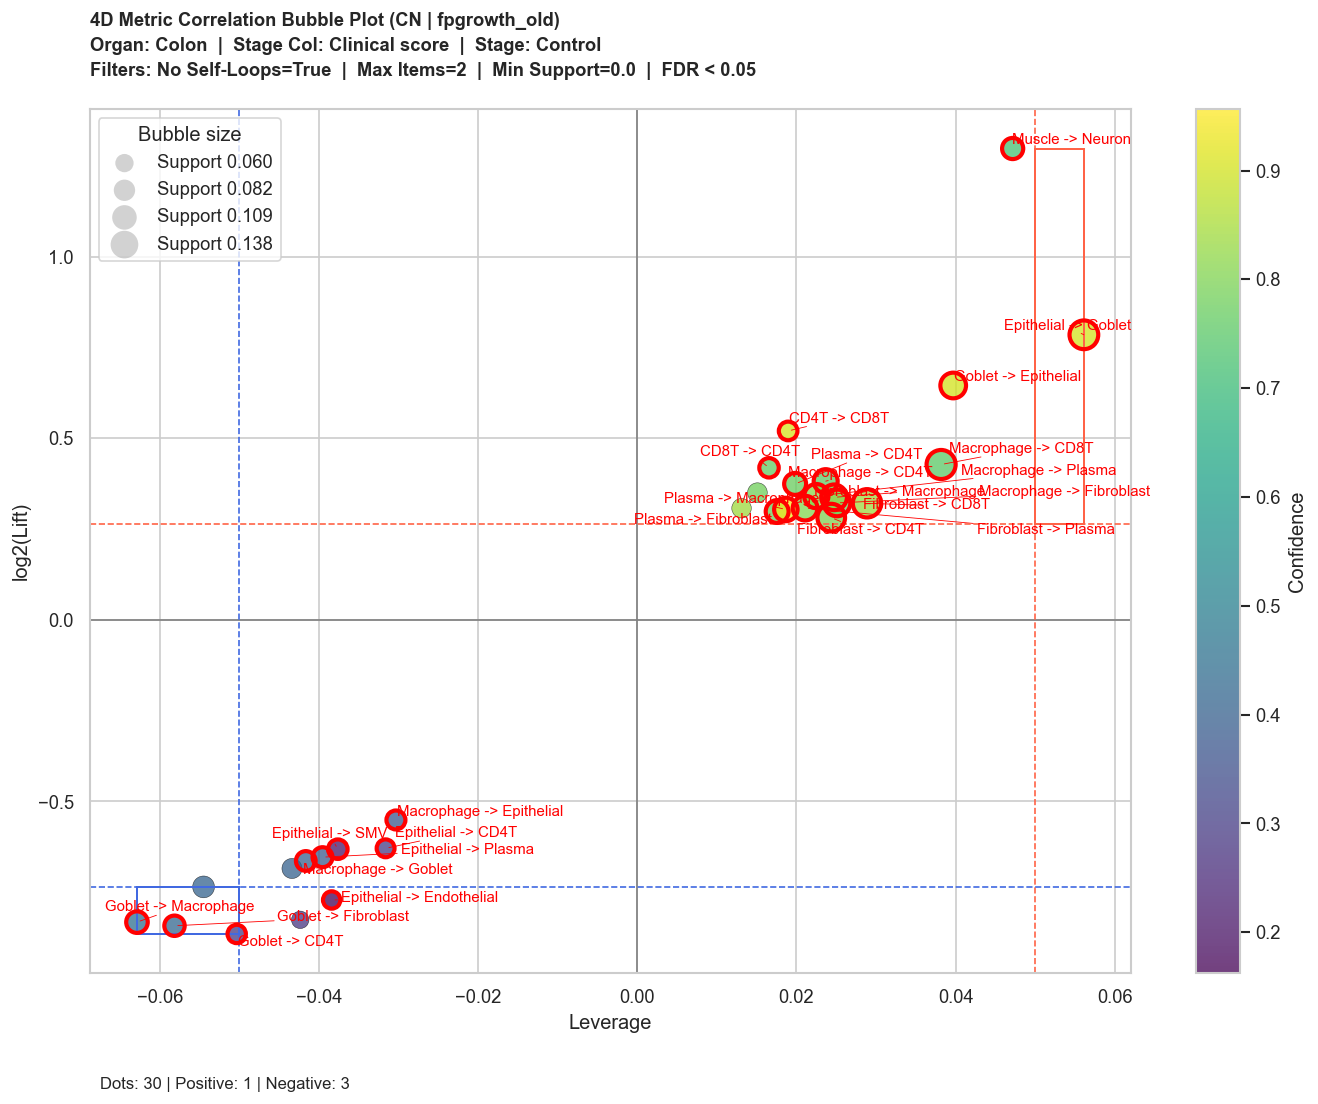

Rules in Positive Zone: 1


,Rule,Leverage,Lift,Log2_Lift,Confidence,Support
5,Epithelial -> Goblet,0.056126,1.723504,0.785345,0.901019,0.148590


Rules in Negative Zone: 3


,Rule,Leverage,Lift,Log2_Lift,Confidence,Support
16,Goblet -> Macrophage,-0.062877,0.561541,-0.832536,0.449958,0.083626
15,Goblet -> Fibroblast,-0.058161,0.557677,-0.842499,0.420942,0.074696
12,Goblet -> CD4T,-0.050342,0.548999,-0.865124,0.298166,0.060645


In [137]:
STAGE = "Control"  # Update this to test different stages
ORGAN = "Colon" 
work_df = _create_basic_dataset(raw_results_df)
metric_df, leverage_source = _build_metric_bubble_df(work_df)

print("filtered work_df:", work_df.shape)
print("metric_df (after FDR + metric filters):", metric_df.shape)
print("leverage_source:", leverage_source)

print(metric_df.head(8))


plot_figure = _plot_metric_bubble(metric_df, leverage_source)
plt.show()

_build_and_display_filtered_zone_dataset(metric_df)

Initial rules count: 18574
Rules count after removing self-overlapping rules: 10419
Rules count after filtering by subset rule items: 1577
Rules count after filtering by minimum support: 1577
Rules count after filtering by stage: 666
Rules count after filtering by organ: 94
metric_df number of lines: 94
filtered work_df: (94, 30)
metric_df (after FDR + metric filters): (31, 8)
leverage_source: mean of per-FOV Leverage
                        Rule      Lift  Confidence   Support  Leverage  \
0             CD4T -> Goblet  0.622305    0.371739  0.072859 -0.044220   
1               CD4T -> Treg  1.478496    0.828966  0.113979  0.031310   
2         CD8T -> Macrophage  1.292419    0.938776  0.053676  0.012144   
3         Epithelial -> CD4T  0.656552    0.154455  0.055437 -0.029000   
4   Epithelial -> Fibroblast  0.640452    0.338362  0.132713 -0.074505   
5       Epithelial -> Goblet  1.667054    0.903211  0.217565  0.068713   
6  Epithelial -> ImmuneOther  0.679934    0.196296  0.075499

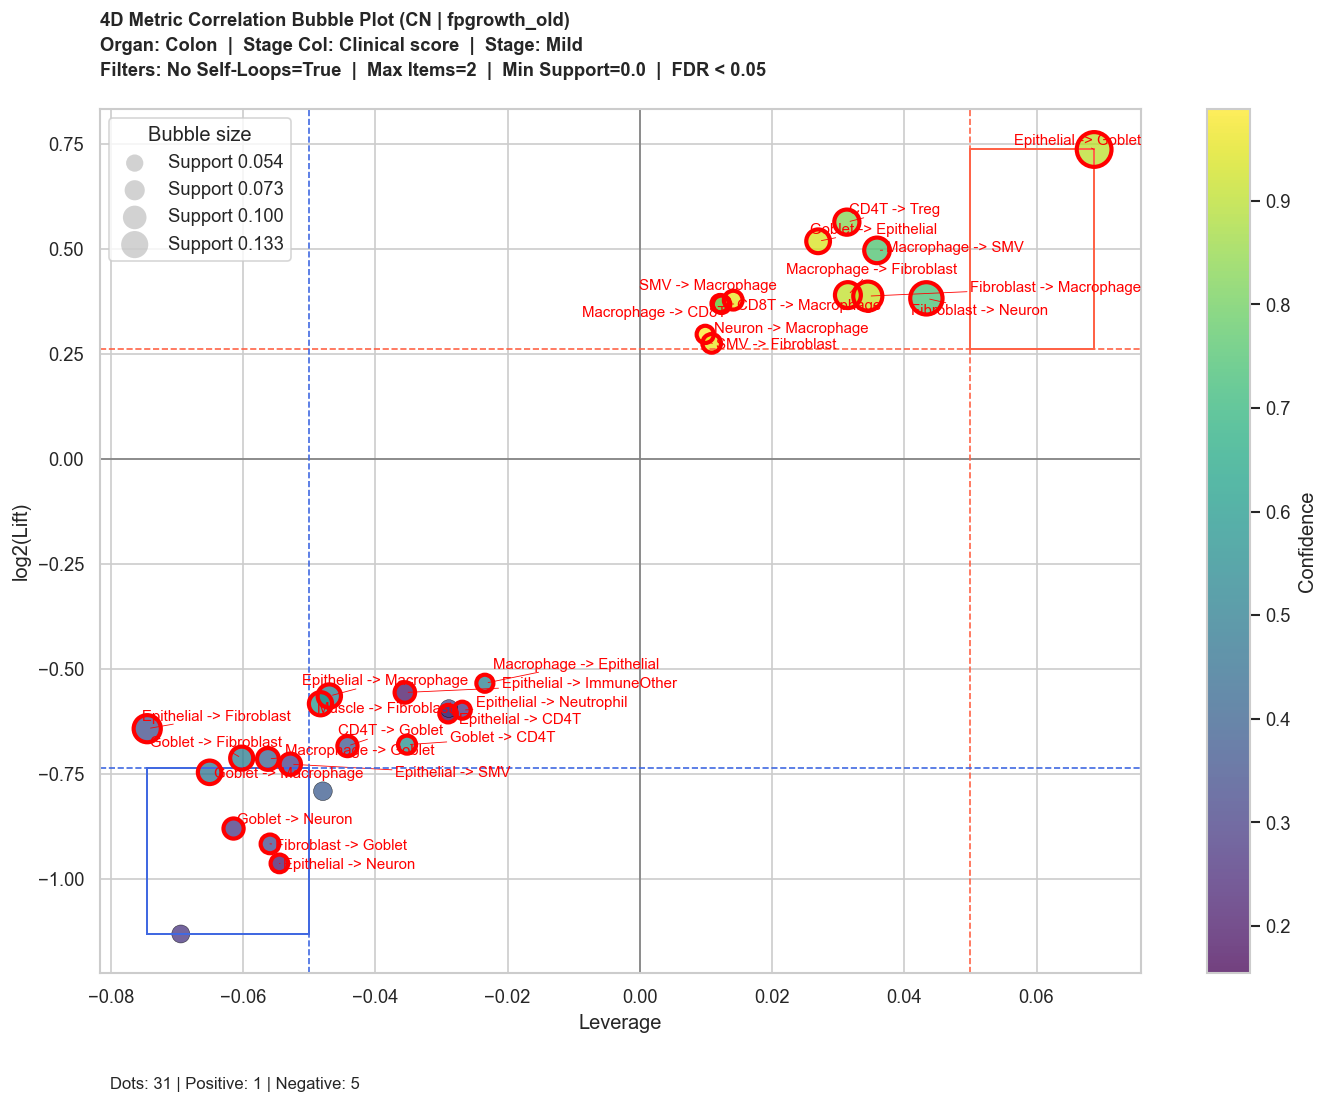

Rules in Positive Zone: 1


,Rule,Leverage,Lift,Log2_Lift,Confidence,Support
5,Epithelial -> Goblet,0.068713,1.667054,0.737300,0.903211,0.217565


Rules in Negative Zone: 5


,Rule,Leverage,Lift,Log2_Lift,Confidence,Support
20,Goblet -> SMV,-0.069425,0.456288,-1.131984,0.272560,0.058394
18,Goblet -> Macrophage,-0.065069,0.595921,-0.746807,0.468418,0.099353
19,Goblet -> Neuron,-0.061447,0.543084,-0.880754,0.274267,0.073167
11,Fibroblast -> Goblet,-0.055938,0.529470,-0.917379,0.324159,0.062945
8,Epithelial -> Neuron,-0.054511,0.512687,-0.963851,0.192461,0.056104


In [138]:
STAGE = "Mild"  # Update this to test different stages
organ = "Colon"
work_df = _create_basic_dataset(raw_results_df)
metric_df, leverage_source = _build_metric_bubble_df(work_df)

print("filtered work_df:", work_df.shape)
print("metric_df (after FDR + metric filters):", metric_df.shape)
print("leverage_source:", leverage_source)

print(metric_df.head(8))


plot_figure = _plot_metric_bubble(metric_df, leverage_source)
plt.show()

_build_and_display_filtered_zone_dataset(metric_df)

Initial rules count: 18574
Rules count after removing self-overlapping rules: 10419
Rules count after filtering by subset rule items: 1577
Rules count after filtering by minimum support: 1577
Rules count after filtering by stage: 375
Rules count after filtering by organ: 220
metric_df number of lines: 220
filtered work_df: (220, 30)
metric_df (after FDR + metric filters): (61, 8)
leverage_source: mean of per-FOV Leverage
                 Rule      Lift  Confidence   Support  Leverage       FDR  \
0         CD4T -> APC  1.950697    0.836013  0.114638  0.055870  0.000999   
1        CD4T -> CD8T  1.569974    0.849398  0.098617  0.037638  0.001077   
2  CD4T -> Fibroblast  1.222717    0.952941  0.088913  0.016196  0.000999   
3  CD4T -> Macrophage  1.256718    0.977360  0.092987  0.018494  0.001068   
4        CD4T -> Treg  1.915263    0.821539  0.113826  0.049172  0.000999   
5        CD8T -> CD4T  1.318365    0.704846  0.069145  0.016479  0.001131   
6  CD8T -> Fibroblast  1.214381    0

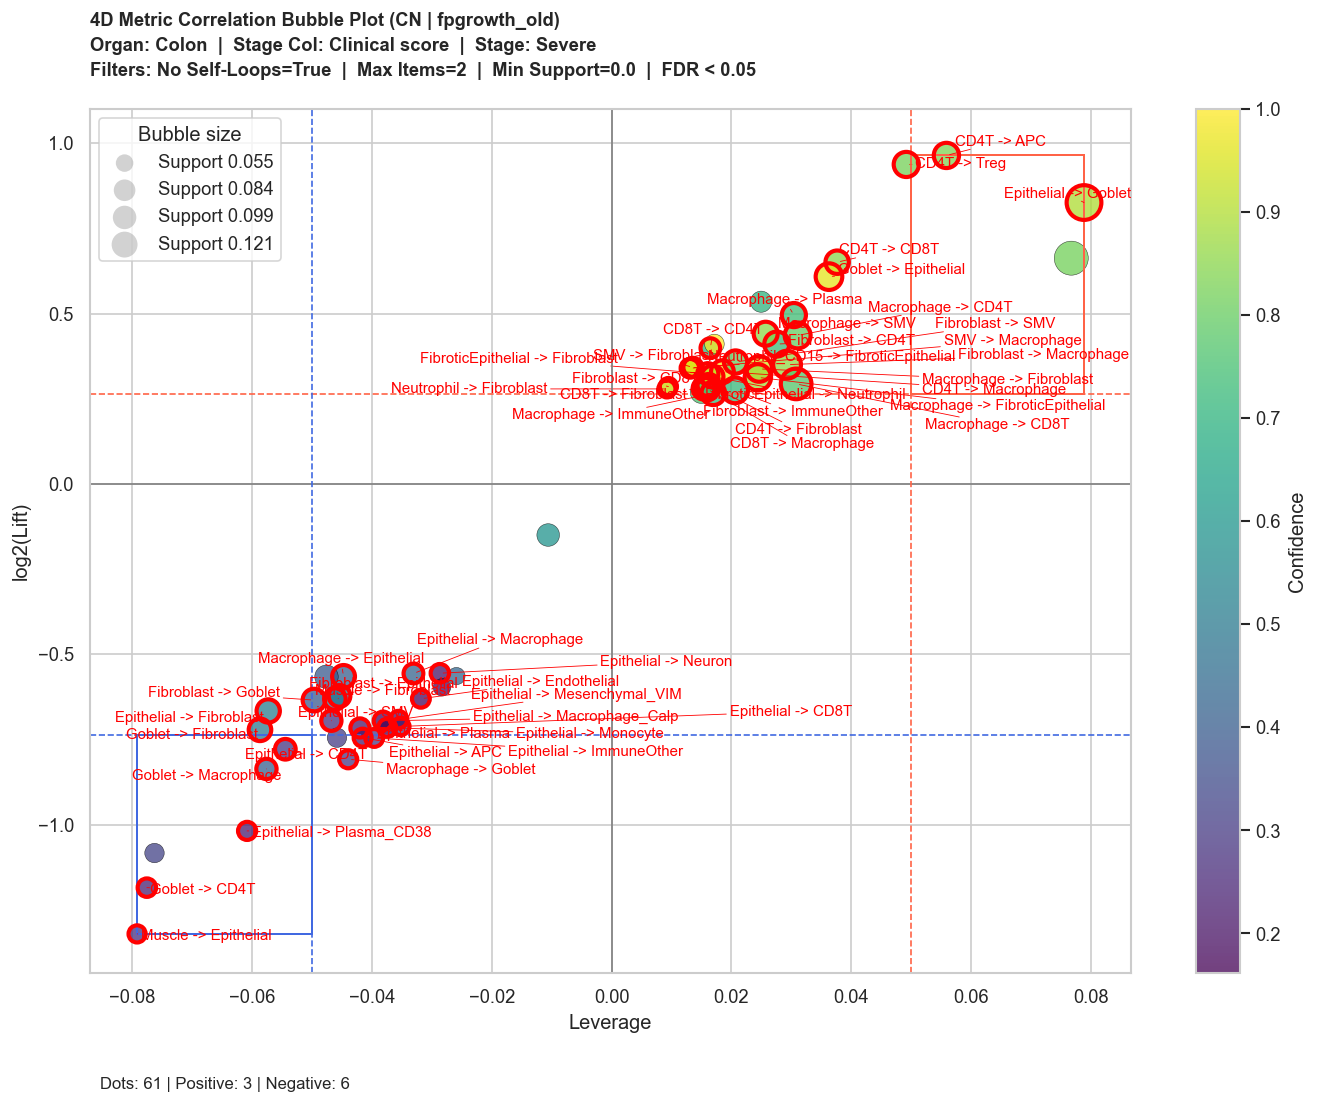

Rules in Positive Zone: 3


,Rule,Leverage,Lift,Log2_Lift,Confidence,Support
13,Epithelial -> Goblet,0.078829,1.772485,0.825774,0.896925,0.217167
54,Neutrophil -> Neutrophil_CD15,0.076707,1.582856,0.662530,0.817992,0.208311
0,CD4T -> APC,0.055870,1.950697,0.963989,0.836013,0.114638


Rules in Negative Zone: 6


,Rule,Leverage,Lift,Log2_Lift,Confidence,Support
50,Muscle -> Epithelial,-0.079175,0.400488,-1.320169,0.270440,0.052891
32,Goblet -> CD4T,-0.077545,0.439999,-1.184426,0.228885,0.061297
38,Goblet -> SMV,-0.076272,0.472092,-1.082861,0.324397,0.068207
21,Epithelial -> Plasma_CD38,-0.060820,0.493845,-1.017869,0.223541,0.059139
36,Goblet -> Macrophage,-0.057590,0.560158,-0.836095,0.404731,0.073890
9,Epithelial -> CD4T,-0.054435,0.583038,-0.778339,0.284848,0.076643


In [139]:
STAGE = "Severe"  # Update this to test different stages
ORGAN = "Colon"
work_df = _create_basic_dataset(raw_results_df)
metric_df, leverage_source = _build_metric_bubble_df(work_df)

print("filtered work_df:", work_df.shape)
print("metric_df (after FDR + metric filters):", metric_df.shape)
print("leverage_source:", leverage_source)

print(metric_df.head(8))


plot_figure = _plot_metric_bubble(metric_df, leverage_source)
plt.show()

_build_and_display_filtered_zone_dataset(metric_df)

## Duodenum's Highest Rules

Initial rules count: 18574
Rules count after removing self-overlapping rules: 10419
Rules count after filtering by subset rule items: 1577
Rules count after filtering by minimum support: 1577
Rules count after filtering by stage: 536
Rules count after filtering by organ: 147
metric_df number of lines: 147
filtered work_df: (147, 30)
metric_df (after FDR + metric filters): (47, 8)
leverage_source: mean of per-FOV Leverage
                         Rule      Lift  Confidence   Support  Leverage  \
0        Bcell -> Plasma_CD38  0.458769    0.097717  0.050759 -0.059883   
1  BrunnerGland -> Neutrophil  1.855578    0.718519  0.074673  0.034430   
2                CD4T -> CD8T  1.347722    0.807944  0.081063  0.020521   
3          CD4T -> Epithelial  0.670245    0.484816  0.066264 -0.033432   
4          CD4T -> Fibroblast  1.281514    0.767857  0.066120  0.014525   
5         CD4T -> ImmuneOther  1.481224    0.746341  0.078907  0.025635   
6          CD4T -> Macrophage  1.207886    0.95918

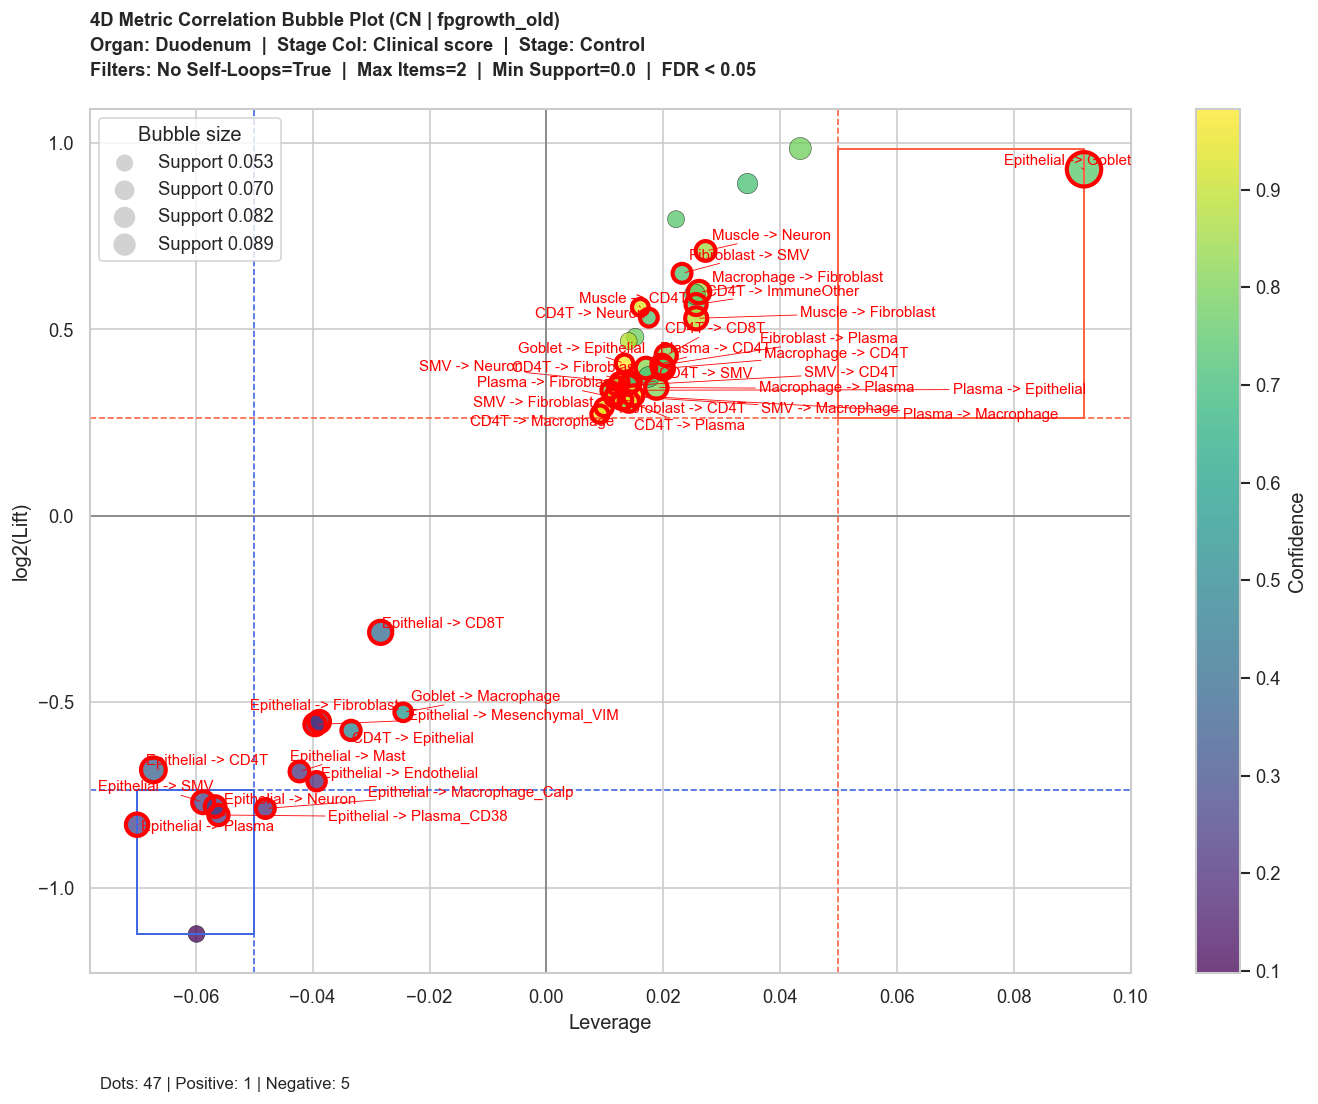

Rules in Positive Zone: 1


,Rule,Leverage,Lift,Log2_Lift,Confidence,Support
14,Epithelial -> Goblet,0.092033,1.905560,0.930215,0.748901,0.212936


Rules in Negative Zone: 5


,Rule,Leverage,Lift,Log2_Lift,Confidence,Support
19,Epithelial -> Plasma,-0.070055,0.562283,-0.830632,0.273602,0.089760
0,Bcell -> Plasma_CD38,-0.059883,0.458769,-1.124161,0.097717,0.050759
21,Epithelial -> SMV,-0.058752,0.586357,-0.770149,0.261652,0.086345
18,Epithelial -> Neuron,-0.056707,0.581586,-0.781935,0.217393,0.076477
20,Epithelial -> Plasma_CD38,-0.056133,0.572573,-0.804469,0.234877,0.073376


In [140]:
STAGE = "Control"  # Update this to test different stages
ORGAN = "Duodenum" 
work_df = _create_basic_dataset(raw_results_df)
metric_df, leverage_source = _build_metric_bubble_df(work_df)

print("filtered work_df:", work_df.shape)
print("metric_df (after FDR + metric filters):", metric_df.shape)
print("leverage_source:", leverage_source)

print(metric_df.head(8))


plot_figure = _plot_metric_bubble(metric_df, leverage_source)
plt.show()

_build_and_display_filtered_zone_dataset(metric_df)

Initial rules count: 18574
Rules count after removing self-overlapping rules: 10419
Rules count after filtering by subset rule items: 1577
Rules count after filtering by minimum support: 1577
Rules count after filtering by stage: 666
Rules count after filtering by organ: 572
metric_df number of lines: 572
filtered work_df: (572, 30)
metric_df (after FDR + metric filters): (102, 8)
leverage_source: mean of per-FOV Leverage
                         Rule      Lift  Confidence   Support  Leverage  \
0                 APC -> CD4T  1.271793    0.740741  0.074731  0.015971   
1  BrunnerGland -> Epithelial  0.472644    0.312925  0.066715 -0.074438   
2  BrunnerGland -> Macrophage  0.579040    0.489011  0.051061 -0.037122   
3        BrunnerGland -> Mast  0.656135    0.251701  0.053662 -0.028123   
4                 CD4T -> APC  1.342803    0.726804  0.098601  0.025172   
5                CD4T -> CD8T  1.562155    0.741572  0.075952  0.024489   
6          CD4T -> Epithelial  0.620687    0.3465

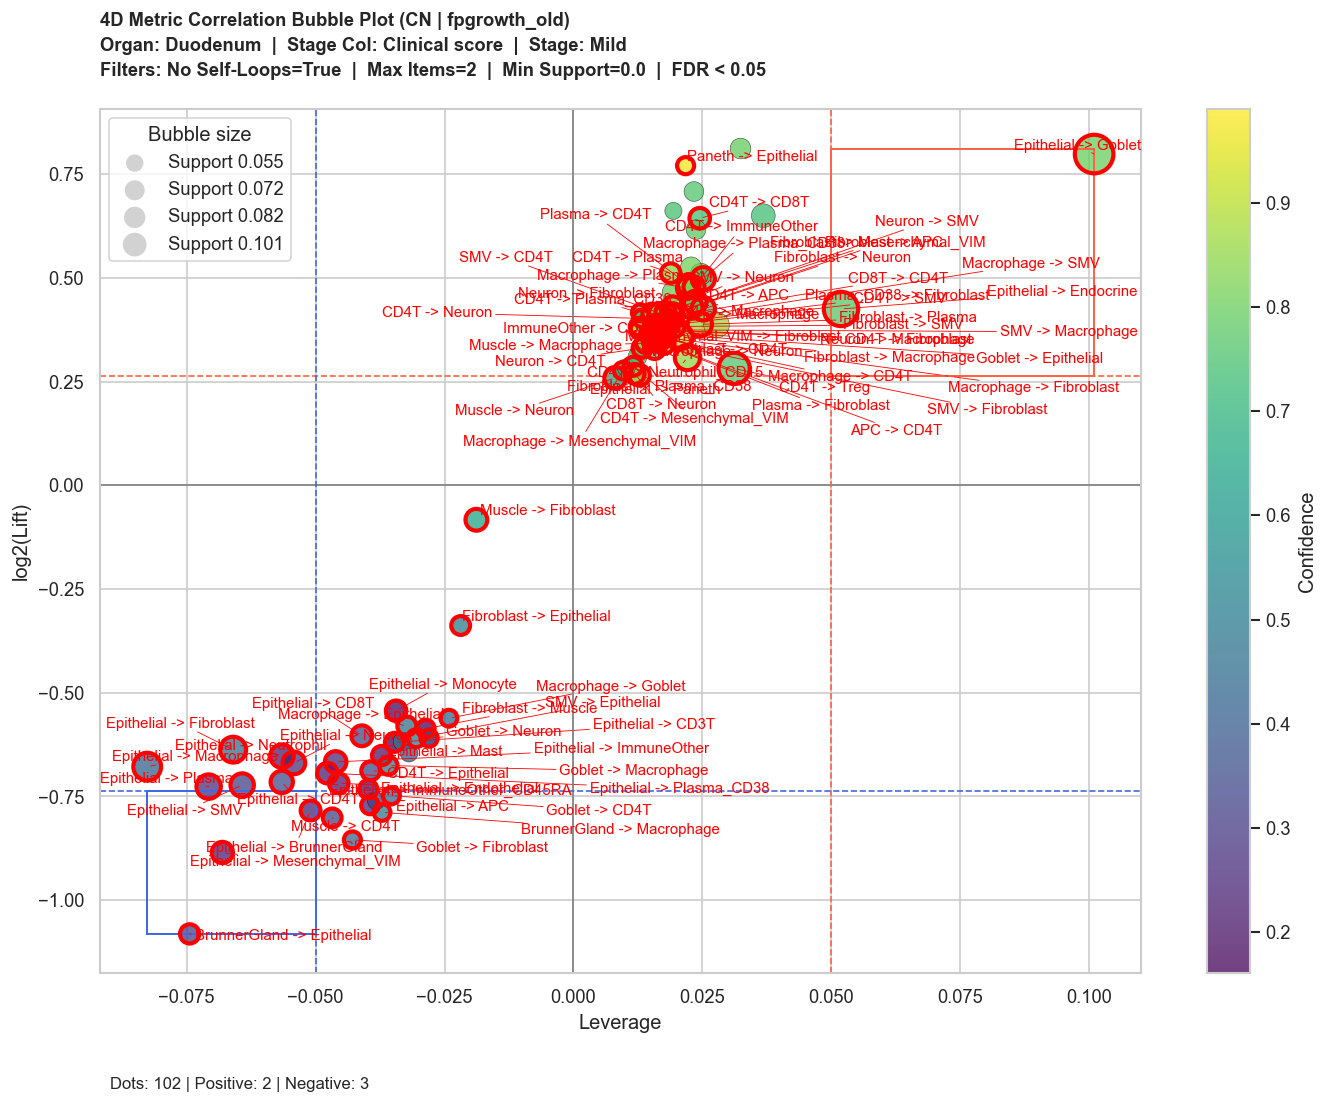

Rules in Positive Zone: 2


,Rule,Leverage,Lift,Log2_Lift,Confidence,Support
28,Epithelial -> Goblet,0.100980,1.738914,0.798187,0.799207,0.268148
25,Epithelial -> Endocrine,0.051885,1.342506,0.424929,0.770136,0.212533


Rules in Negative Zone: 3


,Rule,Leverage,Lift,Log2_Lift,Confidence,Support
1,BrunnerGland -> Epithelial,-0.074438,0.472644,-1.081175,0.312925,0.066715
33,Epithelial -> Mesenchymal_VIM,-0.068098,0.541524,-0.884903,0.230591,0.080888
21,Epithelial -> BrunnerGland,-0.050984,0.580861,-0.783735,0.239938,0.070504


In [141]:
STAGE = "Mild"  # Update this to test different stages
organ = "Duodenum"
work_df = _create_basic_dataset(raw_results_df)
metric_df, leverage_source = _build_metric_bubble_df(work_df)

print("filtered work_df:", work_df.shape)
print("metric_df (after FDR + metric filters):", metric_df.shape)
print("leverage_source:", leverage_source)

print(metric_df.head(8))


plot_figure = _plot_metric_bubble(metric_df, leverage_source)
plt.show()

_build_and_display_filtered_zone_dataset(metric_df)

Initial rules count: 18574
Rules count after removing self-overlapping rules: 10419
Rules count after filtering by subset rule items: 1577
Rules count after filtering by minimum support: 1577
Rules count after filtering by stage: 375
Rules count after filtering by organ: 155
metric_df number of lines: 155
filtered work_df: (155, 30)
metric_df (after FDR + metric filters): (56, 8)
leverage_source: mean of per-FOV Leverage
                            Rule      Lift  Confidence   Support  Leverage  \
0     BrunnerGland -> Macrophage  0.678820    0.594203  0.056787 -0.026868   
1                   CD8T -> CD4T  1.314001    0.703704  0.063881  0.015265   
2                 CD8T -> Neuron  1.305367    0.720183  0.067094  0.015695   
3             Epithelial -> CD4T  0.628426    0.269000  0.086286 -0.050687   
4             Epithelial -> CD8T  0.531200    0.331148  0.096053 -0.084770   
5       Epithelial -> Fibroblast  0.666471    0.526673  0.114880 -0.057842   
6           Epithelial -> Gob

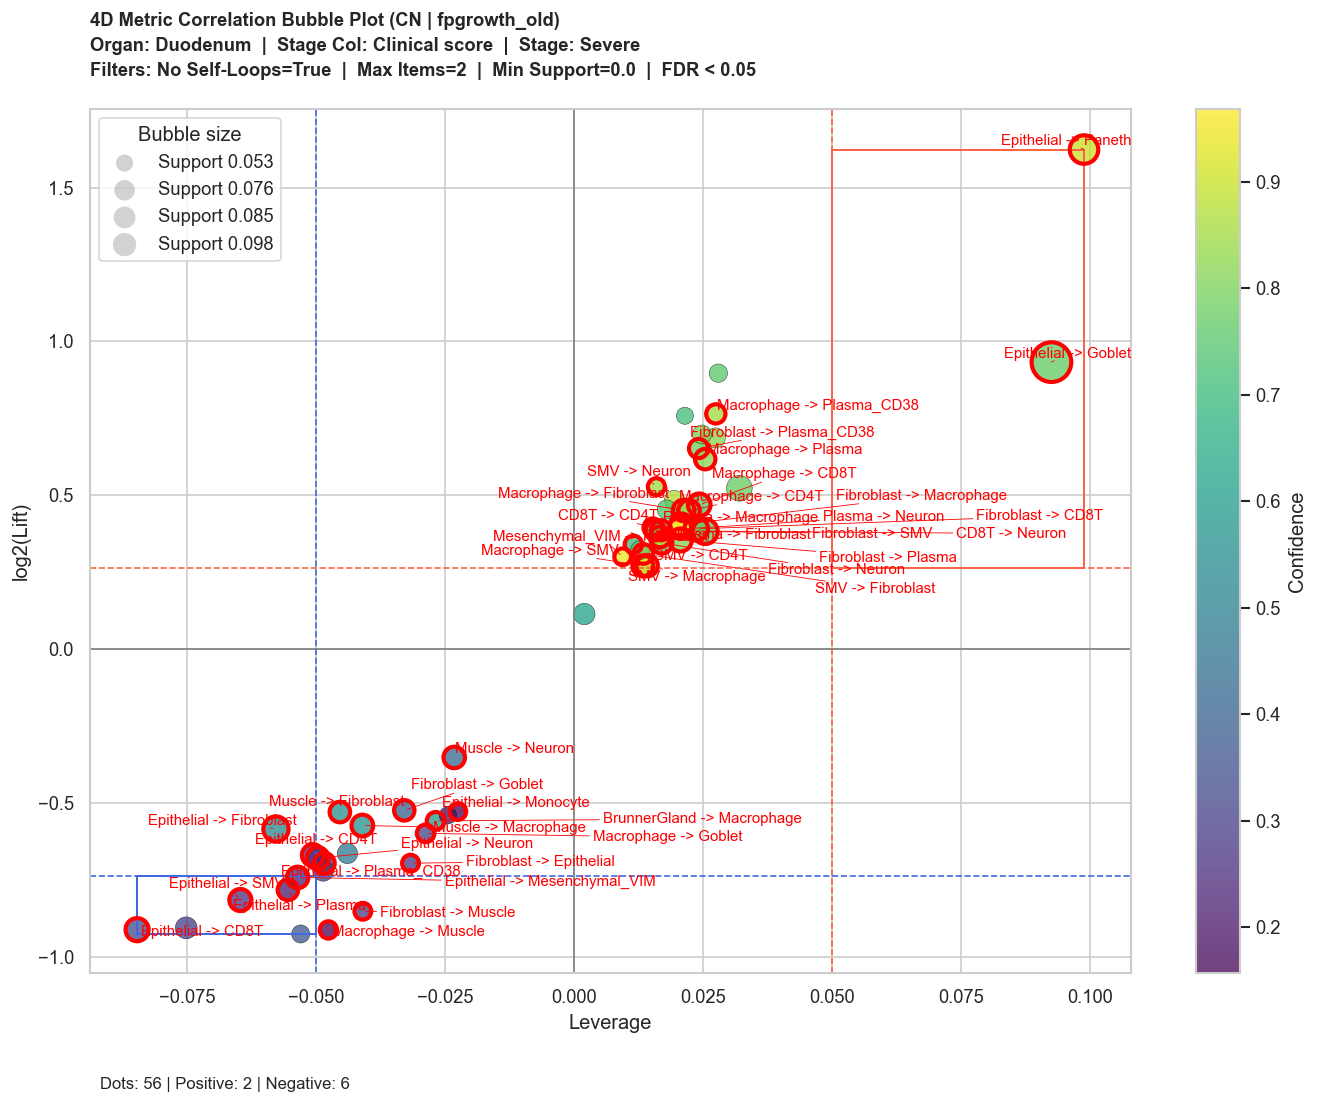

Rules in Positive Zone: 2


,Rule,Leverage,Lift,Log2_Lift,Confidence,Support
10,Epithelial -> Paneth,0.098868,3.081683,1.623719,0.895674,0.146362
6,Epithelial -> Goblet,0.092554,1.908617,0.932528,0.770497,0.283428


Rules in Negative Zone: 6


,Rule,Leverage,Lift,Log2_Lift,Confidence,Support
4,Epithelial -> CD8T,-0.084770,0.531200,-0.912673,0.331148,0.096053
37,Muscle -> Mesenchymal_VIM,-0.075238,0.533410,-0.906682,0.295630,0.086013
13,Epithelial -> SMV,-0.064745,0.567913,-0.816258,0.255496,0.087383
11,Epithelial -> Plasma,-0.055525,0.581089,-0.783169,0.208081,0.075420
7,Epithelial -> Mesenchymal_VIM,-0.053639,0.597600,-0.742748,0.226656,0.083120
35,Muscle -> ImmuneOther,-0.053042,0.526092,-0.926613,0.369085,0.058883


In [142]:
STAGE = "Severe"  # Update this to test different stages
ORGAN = "Duodenum"
work_df = _create_basic_dataset(raw_results_df)
metric_df, leverage_source = _build_metric_bubble_df(work_df)

print("filtered work_df:", work_df.shape)
print("metric_df (after FDR + metric filters):", metric_df.shape)
print("leverage_source:", leverage_source)

print(metric_df.head(8))


plot_figure = _plot_metric_bubble(metric_df, leverage_source)
plt.show()

_build_and_display_filtered_zone_dataset(metric_df)

In [143]:
zone_summary_df = _summarize_threshold_zones(metric_df)
display(zone_summary_df)

print('\nMean values of the wanted subset:')
display(metric_df[["Leverage", "Lift", "Log2_Lift", "Confidence", "Support"]].mean().to_frame(name="Mean"))


,Zone,Count,Percent
0,Positive zone,2,3.57
1,Negative zone,6,10.71
2,Noise zone,1,1.79
3,Total,56,100.00



Mean values of the wanted subset:


,Mean
Leverage,-0.004649
Lift,1.110799
Log2_Lift,0.016553
Confidence,0.609161
Support,0.079774


## Automated Manager Report Generation
Run this cell to automatically generate a multi-page PDF containing bubble plots and highlight tables.

In [ ]:
import glob
from matplotlib.backends.backend_pdf import PdfPages
import matplotlib.pyplot as plt

# 1. Define combinations
organs_to_run = ["Colon", "Duodenum"]
stages_to_run = ["Control", "Mild", "Severe"]

# 2. Find next running ID
existing_reports = glob.glob("reports/bubble_metrics_report_*.pdf")
ids = []
for f in existing_reports:
    try:
        num_str = f.split("_")[-1].replace(".pdf", "")
        ids.append(int(num_str))
    except ValueError:
        pass
next_id = max(ids) + 1 if ids else 1

report_filename = f"reports/bubble_metrics_report_{next_id:03d}.pdf"
print(f"Generating PDF Report: {report_filename}...")

# 3. Create PDF
with PdfPages(report_filename) as pdf:
    for organ in organs_to_run:
        
        # A. Plot Bubble Charts per Stage
        for stage in stages_to_run:
            print(f"-> Processing Organ: {organ} | Stage: {stage}")
            
            ORGAN = organ
            STAGE = stage
            
            work_df = _create_basic_dataset(raw_results_df)
            if not work_df.empty:
                metric_df, leverage_source = _build_metric_bubble_df(work_df)
                if not metric_df.empty:
                    fig = _plot_metric_bubble(metric_df, leverage_source)
                    if fig is not None:
                        pdf.savefig(fig, bbox_inches='tight')
                        plt.close(fig)
        
        # B. Append the Highlighted Rules Summary Table at the end of the organ's section
        print(f"-> Appending Highlighted Rules Table for Organ: {organ}")
        table_fig = _plot_highlight_rules_table(organ)
        if table_fig is not None:
            pdf.savefig(table_fig, bbox_inches='tight')
            plt.close(table_fig)

print("✅ PDF Report Generation Complete!")

Generating PDF Report: reports/bubble_metrics_report_009.pdf...
-> Processing Organ: Colon | Stage: Control
Initial rules count: 18574
Rules count after removing self-overlapping rules: 10419
Rules count after filtering by subset rule items: 1577
Rules count after filtering by minimum support: 1577
Rules count after filtering by stage: 536
Rules count after filtering by organ: 148
metric_df number of lines: 148
-> Processing Organ: Colon | Stage: Mild
Initial rules count: 18574
Rules count after removing self-overlapping rules: 10419
Rules count after filtering by subset rule items: 1577
Rules count after filtering by minimum support: 1577
Rules count after filtering by stage: 666
Rules count after filtering by organ: 94
metric_df number of lines: 94
-> Processing Organ: Colon | Stage: Severe
Initial rules count: 18574
Rules count after removing self-overlapping rules: 10419
Rules count after filtering by subset rule items: 1577
Rules count after filtering by minimum support: 1577
Rule

: 